# Анализ бенчмарка I/O моделей Linux/Java

Сравнение: **Blocking** vs **NIO** vs **Epoll** vs **io_uring**

JDK 21 / Netty 4.1.x / Linux

## Конфигурация машины

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import subprocess
from pathlib import Path

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

RESULTS_DIR = Path('/ssd/benchmark/results')

MODELS = ['blocking', 'nio', 'epoll', 'iouring']
MODEL_COLORS = {'blocking': '#e74c3c', 'nio': '#3498db', 'epoll': '#2ecc71', 'iouring': '#9b59b6'}
MODEL_LABELS = {'blocking': 'Blocking I/O', 'nio': 'NIO (Selector)', 'epoll': 'Epoll (native)', 'iouring': 'io_uring'}

# Конфигурация машины
print("=" * 60)
print("КОНФИГУРАЦИЯ МАШИНЫ")
print("=" * 60)
for cmd, label in [
    ("uname -r", "Kernel"),
    ("lscpu | grep 'Model name'", "CPU"),
    ("lscpu | grep '^CPU(s):'", "CPU cores"),
    ("free -h | grep Mem | awk '{print $2}'", "RAM"),
    ("java -version 2>&1 | head -1", "JDK"),
    ("cat /etc/os-release | grep PRETTY_NAME | cut -d= -f2", "OS"),
]:
    try:
        result = subprocess.check_output(cmd, shell=True, text=True).strip()
        print(f"  {label}: {result}")
    except Exception:
        pass
print("=" * 60)

print(f'\nResults directory: {RESULTS_DIR}')
if RESULTS_DIR.exists():
    dirs = sorted([d.name for d in RESULTS_DIR.iterdir() if d.is_dir()])
    print(f'Found {len(dirs)} result directories')
else:
    print('Results directory not found. Run benchmarks first.')

КОНФИГУРАЦИЯ МАШИНЫ
  Kernel: 6.14.0-37-generic
  CPU: Model name:                              11th Gen Intel(R) Core(TM) i7-11700KF @ 3.60GHz
BIOS Model name:                         11th Gen Intel(R) Core(TM) i7-11700KF @ 3.60GHz To Be Filled By O.E.M. CPU @ 3.6GHz
  CPU cores: CPU(s):                                  16
  RAM: 31Gi
  JDK: openjdk version "21.0.10" 2026-01-20
  OS: "Ubuntu 24.04.3 LTS"

Results directory: /ssd/benchmark/results
Found 960 result directories


In [2]:
def parse_dir_name(dirname):
    """Parse result directory name into components.
    Format: {model}_{cpu}c_{conns}conn_{size}_run{N}
    """
    pattern = r'^(blocking|nio|epoll|iouring)_(\d+)c_(\d+)conn_(\d+)_run(\d+)$'
    match = re.match(pattern, dirname)
    if not match:
        return None
    return {
        'model': match.group(1),
        'cores': int(match.group(2)),
        'connections': int(match.group(3)),
        'data_size': int(match.group(4)),
        'run': int(match.group(5))
    }

def load_all_results():
    """Load and aggregate all benchmark results."""
    all_throughput = []
    all_latency = []
    all_cpu = []
    all_cs = []
    all_memory = []
    all_fd = []
    all_syscalls = []
    
    if not RESULTS_DIR.exists():
        return {}
    
    for d in sorted(RESULTS_DIR.iterdir()):
        if not d.is_dir():
            continue
        meta = parse_dir_name(d.name)
        if meta is None:
            continue
        
        for csv_name, target_list in [
            ('throughput.csv', all_throughput),
            ('latency.csv', all_latency),
            ('cpu.csv', all_cpu),
            ('context_switches.csv', all_cs),
            ('memory.csv', all_memory),
            ('fd_count.csv', all_fd),
        ]:
            csv_path = d / csv_name
            if csv_path.exists():
                try:
                    df = pd.read_csv(csv_path)
                    for k, v in meta.items():
                        df[k] = v
                    target_list.append(df)
                except Exception:
                    pass
        
        # Syscalls (not per-second, one summary per test)
        sc_path = d / 'syscalls.csv'
        if sc_path.exists():
            try:
                df = pd.read_csv(sc_path)
                for k, v in meta.items():
                    df[k] = v
                all_syscalls.append(df)
            except Exception:
                pass
    
    result = {}
    for name, data_list in [
        ('throughput', all_throughput),
        ('latency', all_latency),
        ('cpu', all_cpu),
        ('context_switches', all_cs),
        ('memory', all_memory),
        ('fd_count', all_fd),
        ('syscalls', all_syscalls),
    ]:
        if data_list:
            result[name] = pd.concat(data_list, ignore_index=True)
    
    return result

data = load_all_results()
print(f'Loaded datasets: {list(data.keys())}')
for k, v in data.items():
    print(f'  {k}: {len(v)} rows')

Loaded datasets: ['throughput', 'latency', 'cpu', 'context_switches', 'memory', 'fd_count', 'syscalls']
  throughput: 28800 rows
  latency: 28800 rows
  cpu: 28800 rows
  context_switches: 28800 rows
  memory: 28800 rows
  fd_count: 28800 rows
  syscalls: 1920 rows


## 1. Throughput vs Connections

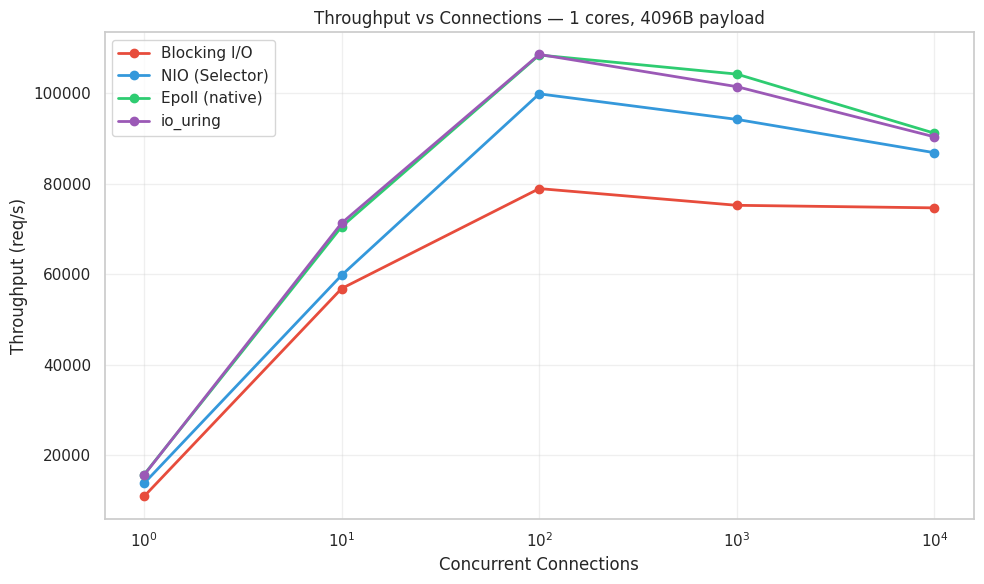

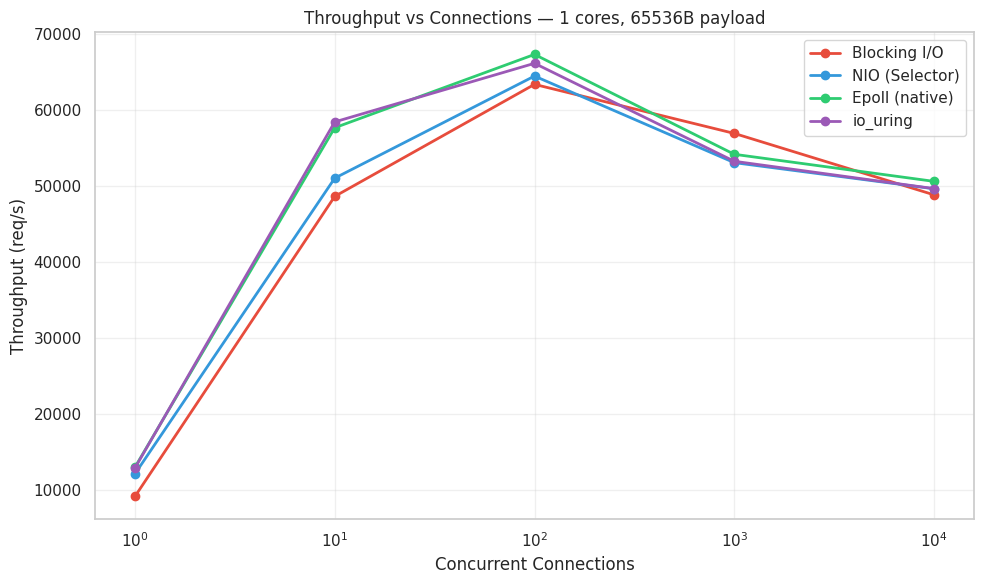

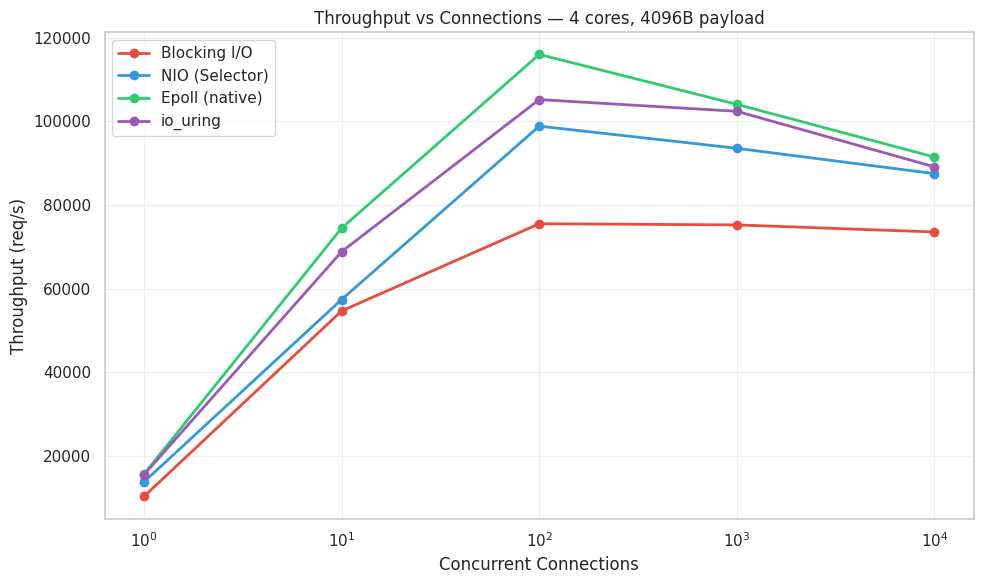

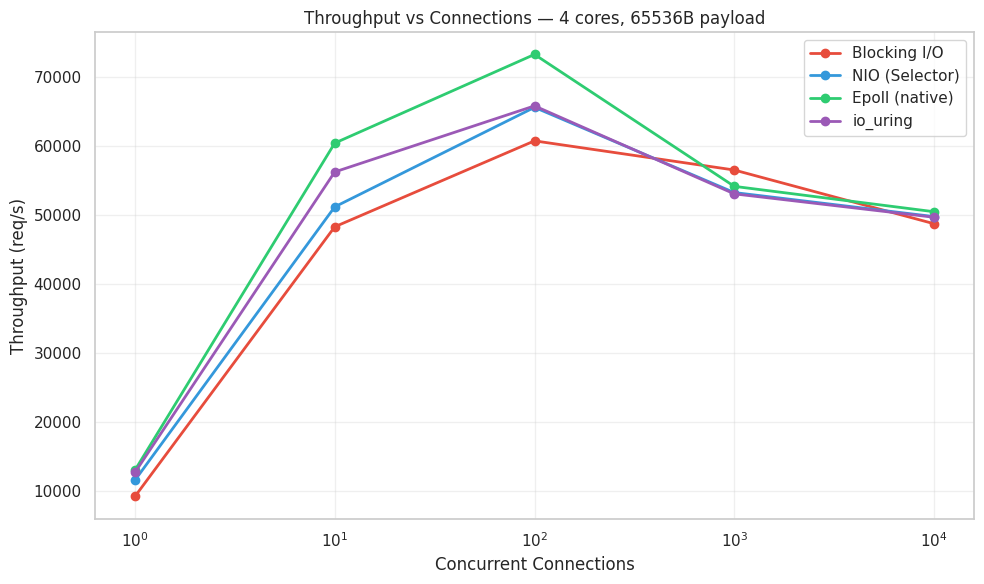

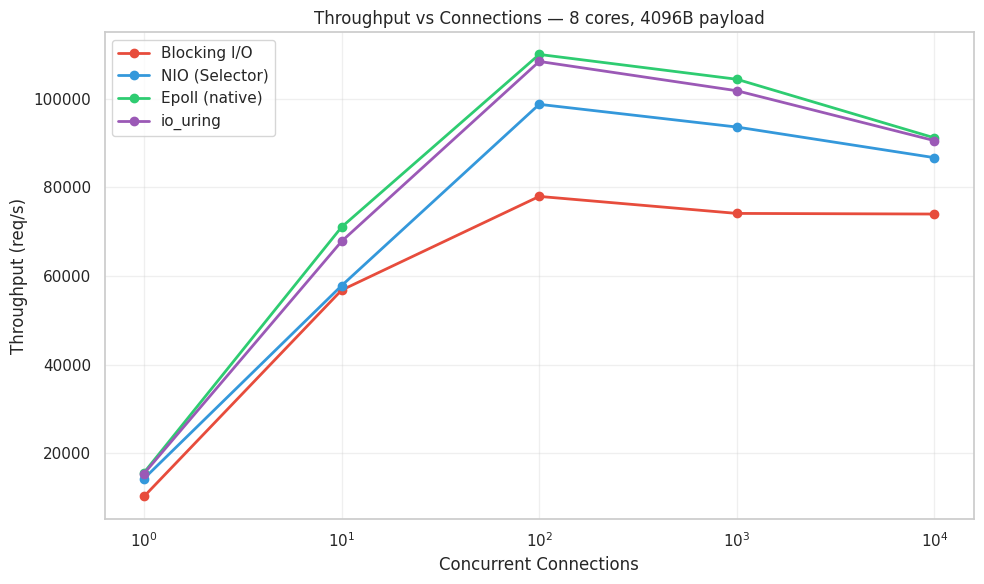

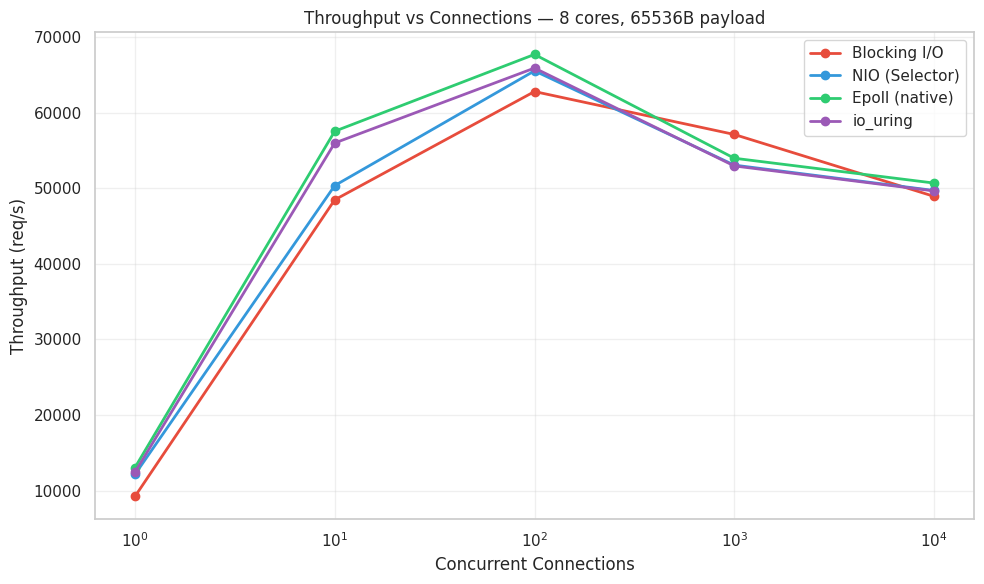

In [3]:
if 'throughput' in data:
    df = data['throughput']
    # Average throughput per (model, cores, connections, data_size) — mean across seconds and runs
    agg = df.groupby(['model', 'cores', 'connections', 'data_size'])['throughput_rps'].mean().reset_index()
    
    for cores in sorted(agg['cores'].unique()):
        for size in [4096, 65536]:  # Show key sizes
            subset = agg[(agg['cores'] == cores) & (agg['data_size'] == size)]
            if subset.empty:
                continue
            
            fig, ax = plt.subplots(figsize=(10, 6))
            for model in MODELS:
                m = subset[subset['model'] == model]
                if not m.empty:
                    ax.plot(m['connections'], m['throughput_rps'], 'o-',
                            color=MODEL_COLORS[model], label=MODEL_LABELS[model], linewidth=2, markersize=6)
            
            ax.set_xscale('log')
            ax.set_xlabel('Concurrent Connections')
            ax.set_ylabel('Throughput (req/s)')
            ax.set_title(f'Throughput vs Connections — {cores} cores, {size}B payload')
            ax.legend()
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
else:
    print('No throughput data available. Run benchmarks first.')

## 1a. Time-Series: изменение метрик во время теста

Графики показывают как каждая метрика меняется по секундам в рамках одного теста.
Выбрана конфигурация: 4 ядра, 1000 соединений, 4KB данных, run 1.

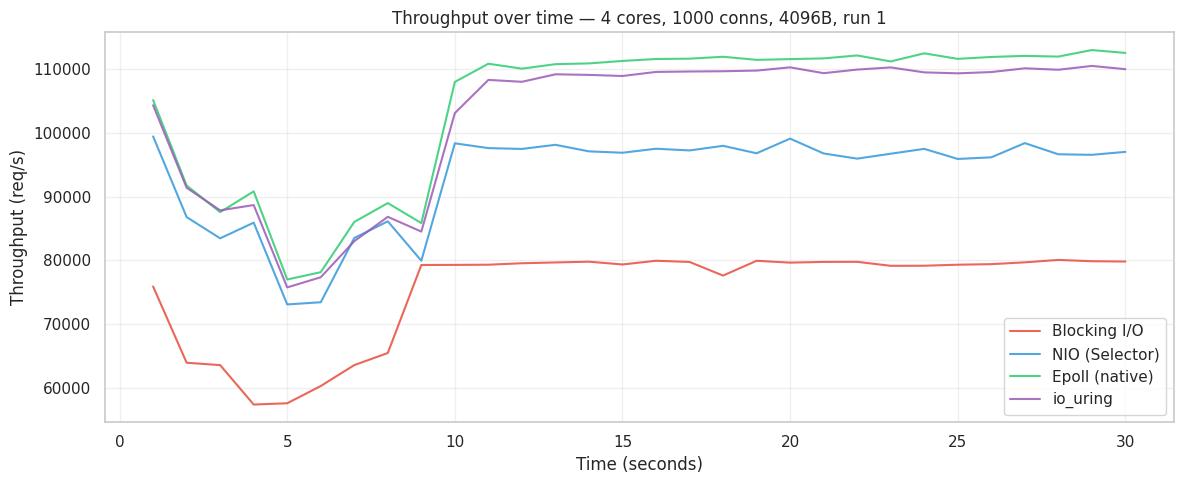

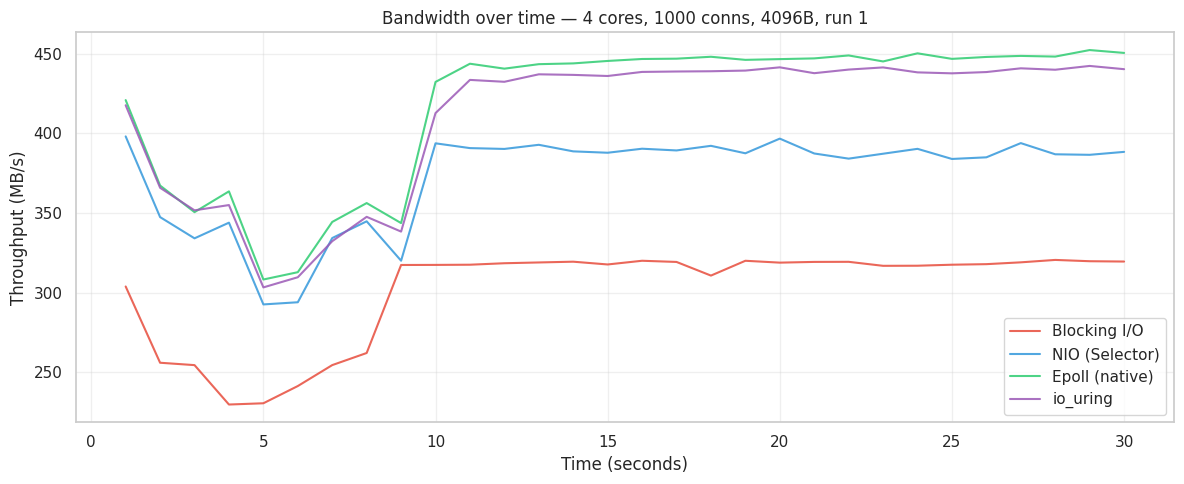

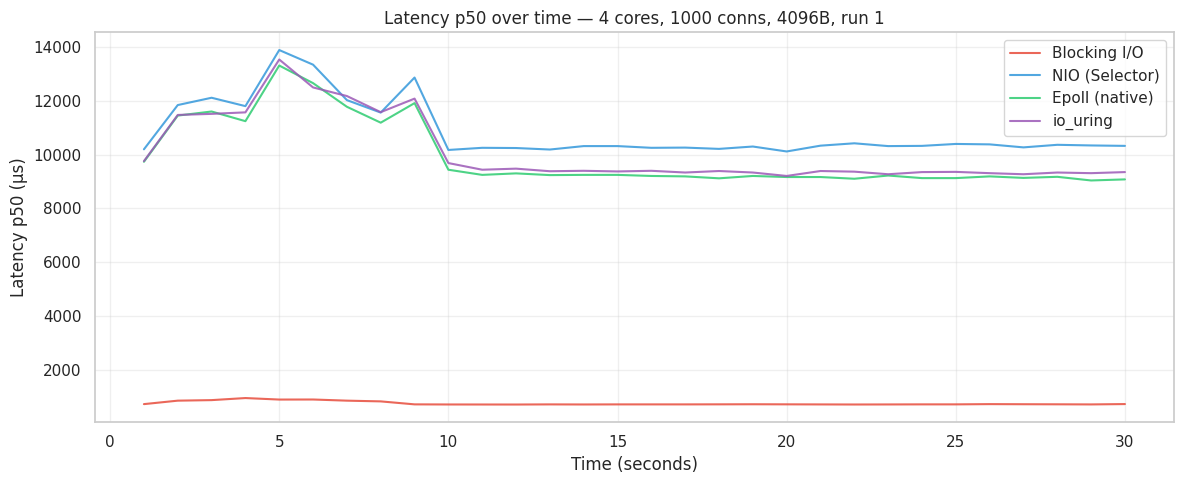

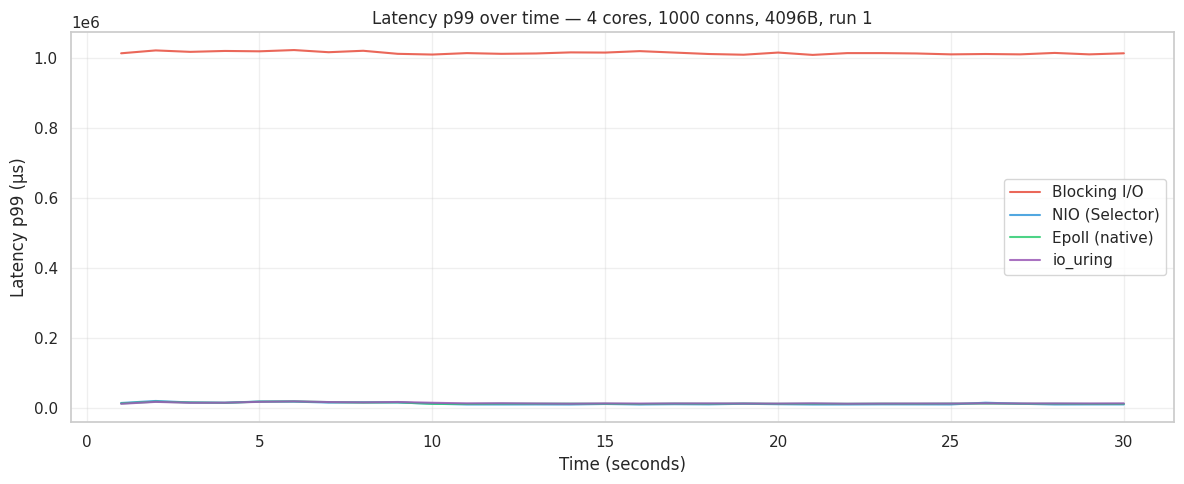

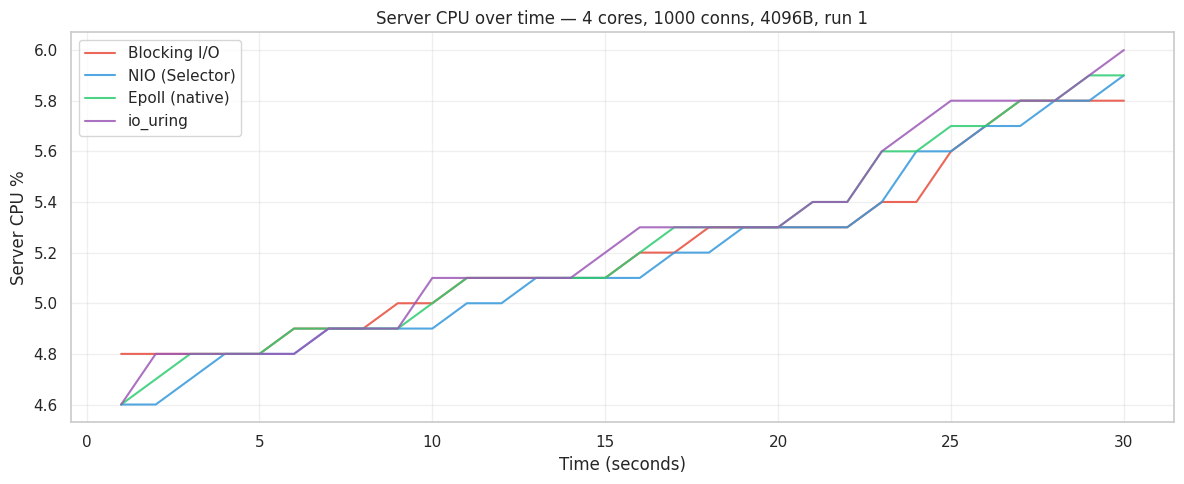

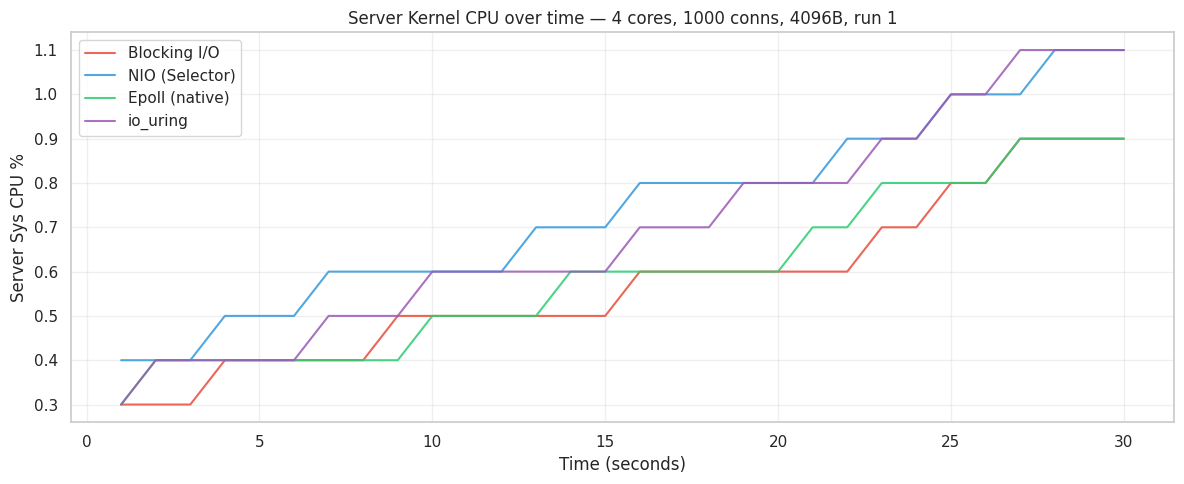

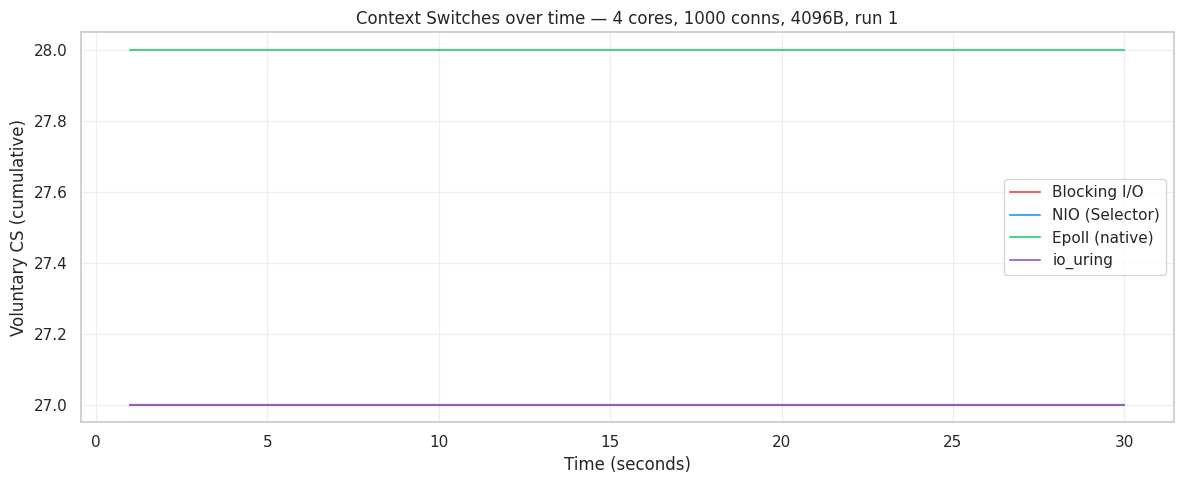

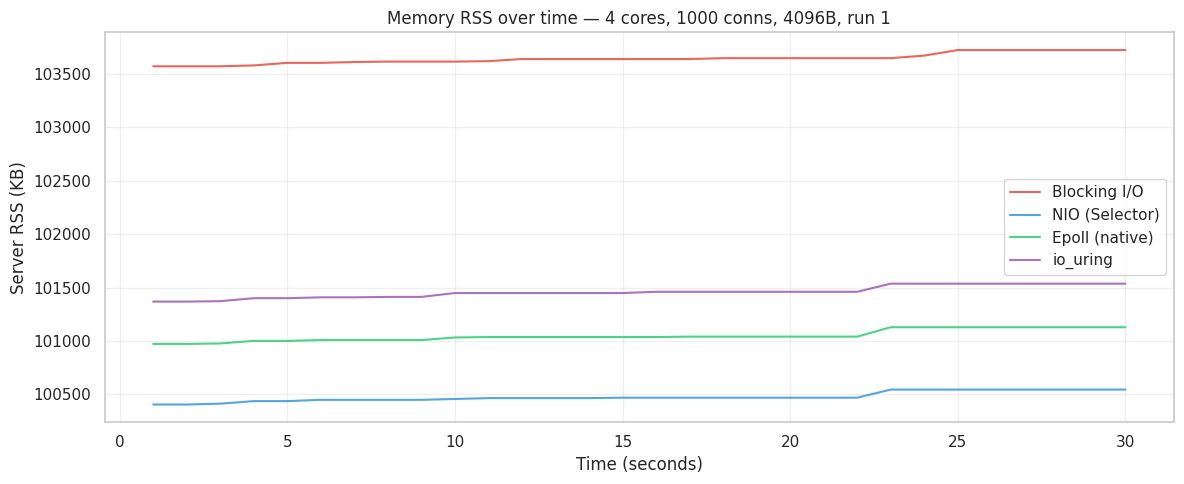

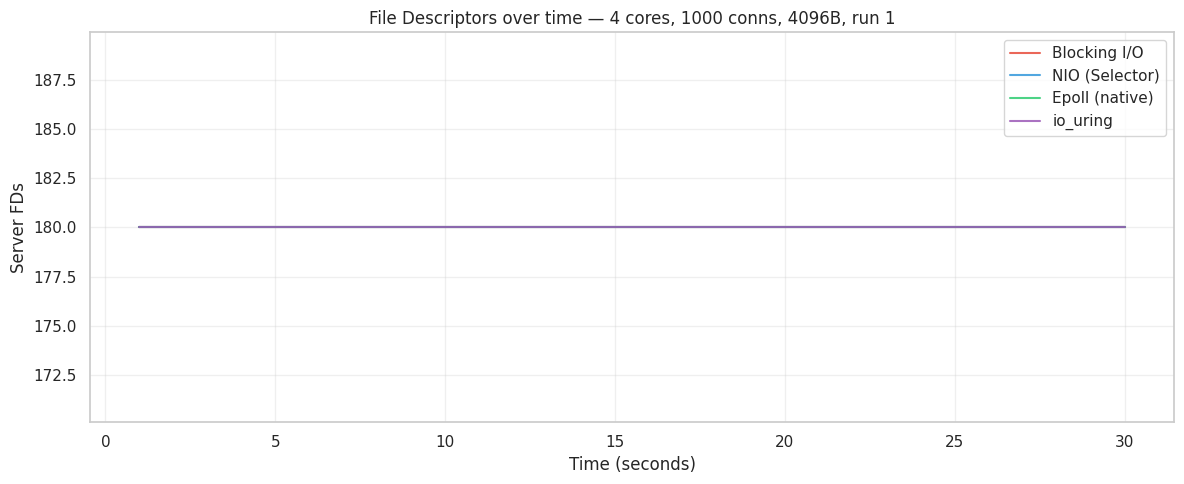

In [4]:
def plot_timeseries(data, cores=4, conns=1000, size=4096, run=1):
    """Plot per-second time-series for all metrics, all models on one graph."""
    filter_kw = dict(cores=cores, connections=conns, data_size=size, run=run)
    title_suffix = f'{cores} cores, {conns} conns, {size}B, run {run}'
    
    metrics_config = [
        ('throughput', 'throughput_rps', 'Throughput (req/s)', f'Throughput over time — {title_suffix}'),
        ('throughput', 'throughput_mbs', 'Throughput (MB/s)', f'Bandwidth over time — {title_suffix}'),
        ('latency', 'p50_us', 'Latency p50 (μs)', f'Latency p50 over time — {title_suffix}'),
        ('latency', 'p99_us', 'Latency p99 (μs)', f'Latency p99 over time — {title_suffix}'),
        ('cpu', 'server_total_pct', 'Server CPU %', f'Server CPU over time — {title_suffix}'),
        ('cpu', 'server_sys_pct', 'Server Sys CPU %', f'Server Kernel CPU over time — {title_suffix}'),
        ('context_switches', 'server_voluntary', 'Voluntary CS (cumulative)', f'Context Switches over time — {title_suffix}'),
        ('memory', 'server_rss_kb', 'Server RSS (KB)', f'Memory RSS over time — {title_suffix}'),
        ('fd_count', 'server_fd_count', 'Server FDs', f'File Descriptors over time — {title_suffix}'),
    ]
    
    for dataset_name, column, ylabel, title in metrics_config:
        if dataset_name not in data:
            continue
        df = data[dataset_name]
        
        # Filter by config
        mask = True
        for k, v in filter_kw.items():
            if k in df.columns:
                mask = mask & (df[k] == v)
        subset = df[mask]
        
        if subset.empty or column not in subset.columns:
            continue
        
        fig, ax = plt.subplots(figsize=(12, 5))
        for model in MODELS:
            m = subset[subset['model'] == model].sort_values('timestamp_sec')
            if not m.empty:
                ax.plot(m['timestamp_sec'], m[column], '-',
                        color=MODEL_COLORS[model], label=MODEL_LABELS[model], linewidth=1.5, alpha=0.85)
        
        ax.set_xlabel('Time (seconds)')
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

if data:
    plot_timeseries(data, cores=4, conns=1000, size=4096, run=1)
else:
    print('No data available for time-series plots.')

## 2. Latency Distribution

/tmp/ipykernel_695197/4030595941.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)
/tmp/ipykernel_695197/4030595941.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)
/tmp/ipykernel_695197/4030595941.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)


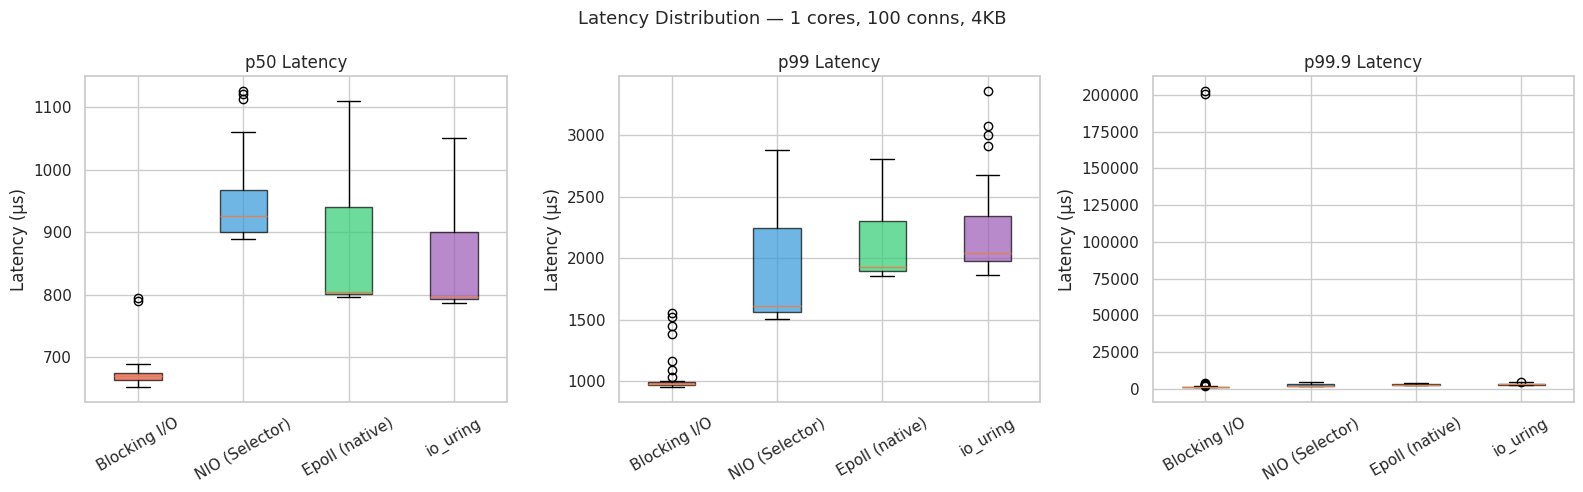

/tmp/ipykernel_695197/4030595941.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)
/tmp/ipykernel_695197/4030595941.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)
/tmp/ipykernel_695197/4030595941.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)


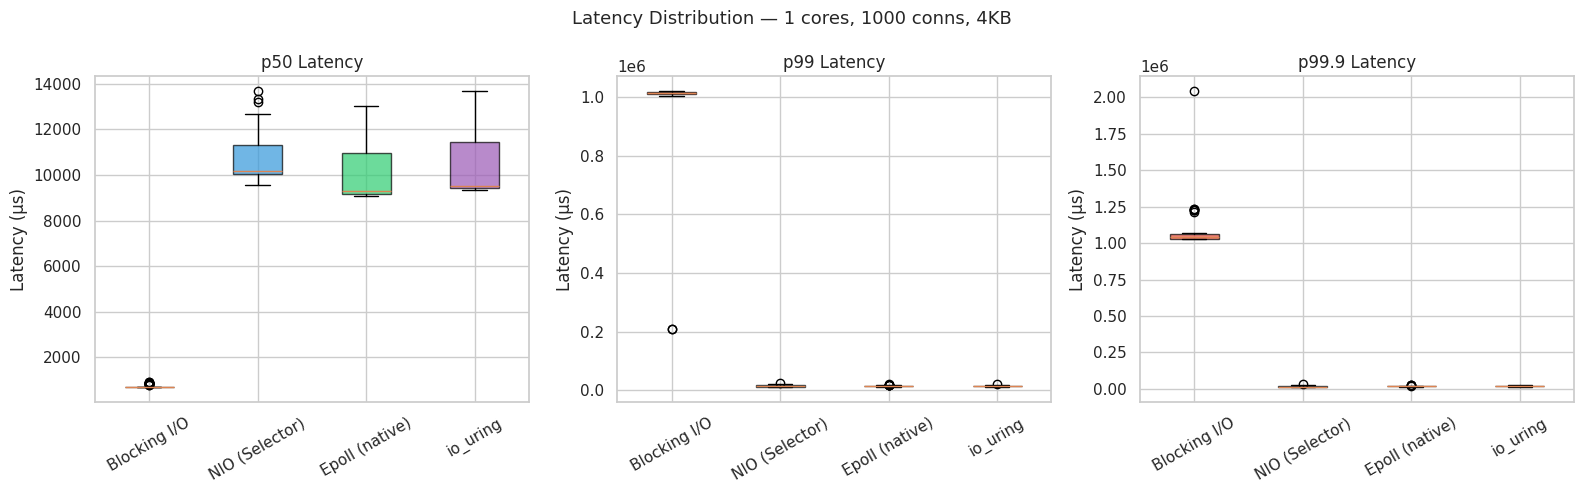

/tmp/ipykernel_695197/4030595941.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)
/tmp/ipykernel_695197/4030595941.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)


/tmp/ipykernel_695197/4030595941.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)


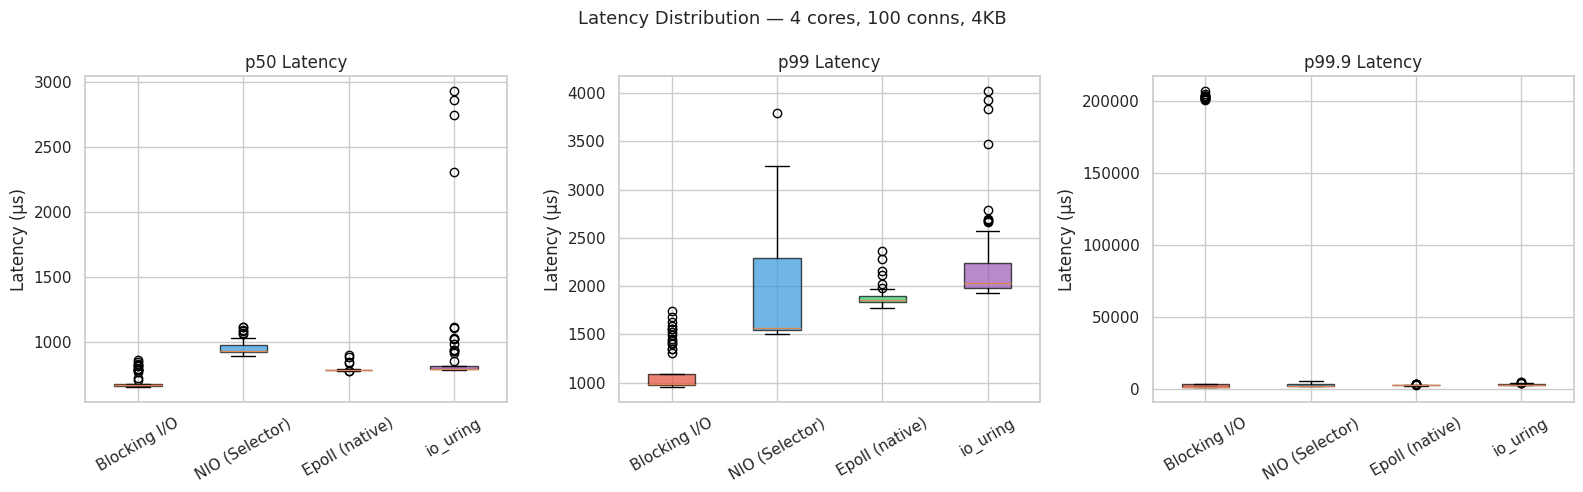

/tmp/ipykernel_695197/4030595941.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)
/tmp/ipykernel_695197/4030595941.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)
/tmp/ipykernel_695197/4030595941.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)


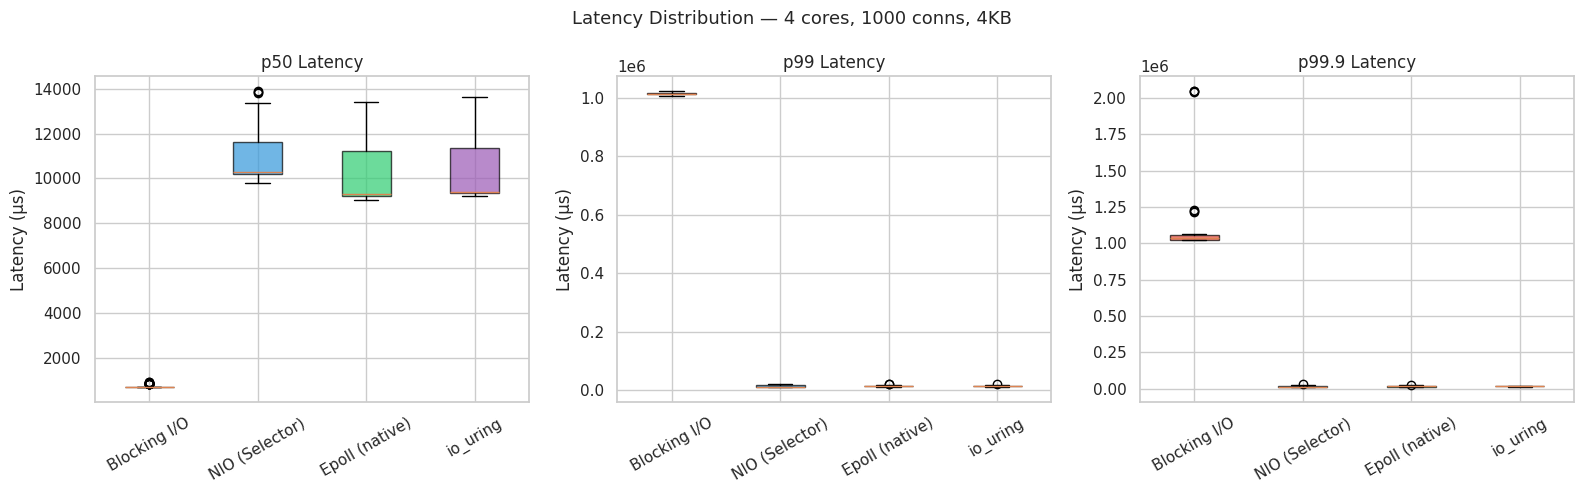

/tmp/ipykernel_695197/4030595941.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)


/tmp/ipykernel_695197/4030595941.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)
/tmp/ipykernel_695197/4030595941.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)


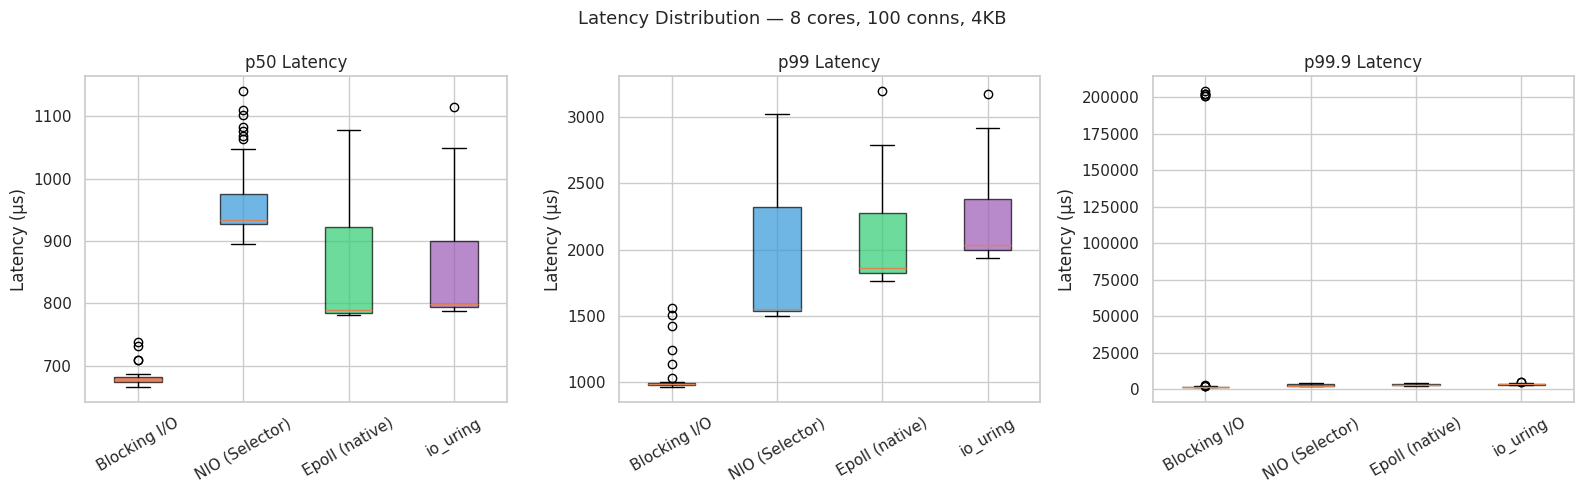

/tmp/ipykernel_695197/4030595941.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)
/tmp/ipykernel_695197/4030595941.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)
/tmp/ipykernel_695197/4030595941.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)


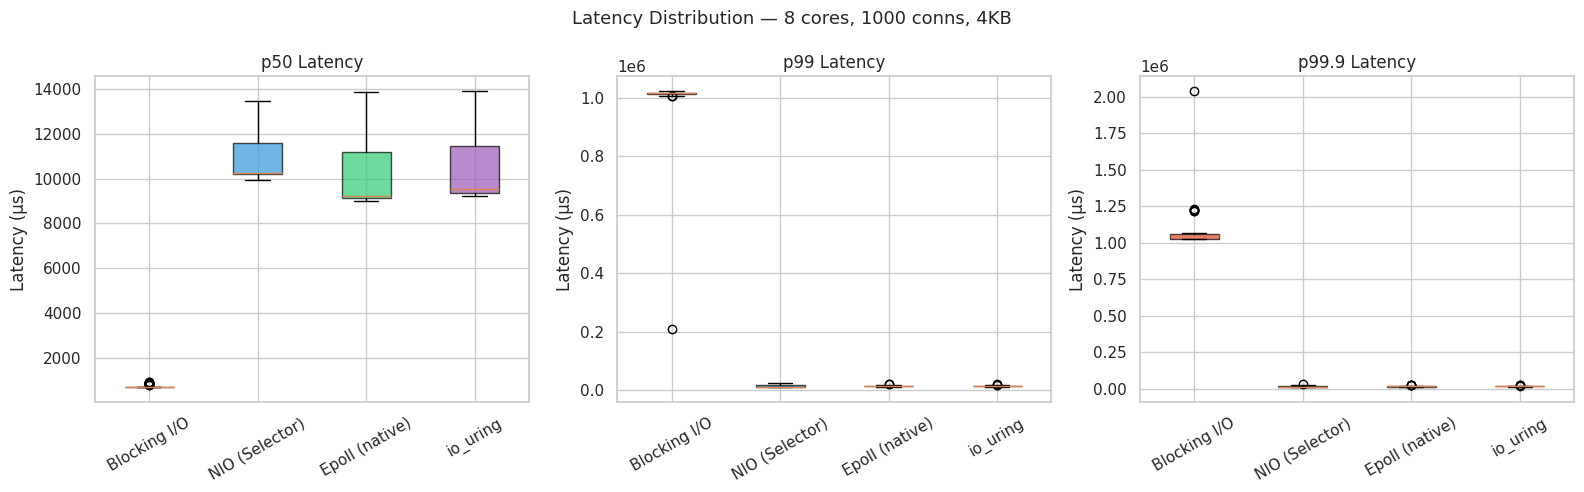

In [5]:
if 'latency' in data:
    df = data['latency']
    
    for cores in sorted(df['cores'].unique()):
        for conns in [100, 1000]:
            subset = df[(df['cores'] == cores) & (df['connections'] == conns) & (df['data_size'] == 4096)]
            if subset.empty:
                continue
            
            fig, axes = plt.subplots(1, 3, figsize=(16, 5))
            for ax, metric, label in zip(axes, ['p50_us', 'p99_us', 'p999_us'], ['p50', 'p99', 'p99.9']):
                plot_data = []
                labels = []
                colors = []
                for model in MODELS:
                    m = subset[subset['model'] == model][metric]
                    if not m.empty:
                        plot_data.append(m.values)
                        labels.append(MODEL_LABELS[model])
                        colors.append(MODEL_COLORS[model])
                
                if plot_data:
                    bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)
                    for patch, color in zip(bp['boxes'], colors):
                        patch.set_facecolor(color)
                        patch.set_alpha(0.7)
                    ax.set_ylabel('Latency (μs)')
                    ax.set_title(f'{label} Latency')
                    ax.tick_params(axis='x', rotation=30)
            
            fig.suptitle(f'Latency Distribution — {cores} cores, {conns} conns, 4KB', fontsize=13)
            plt.tight_layout()
            plt.show()
else:
    print('No latency data available.')

## 3. CPU Utilization

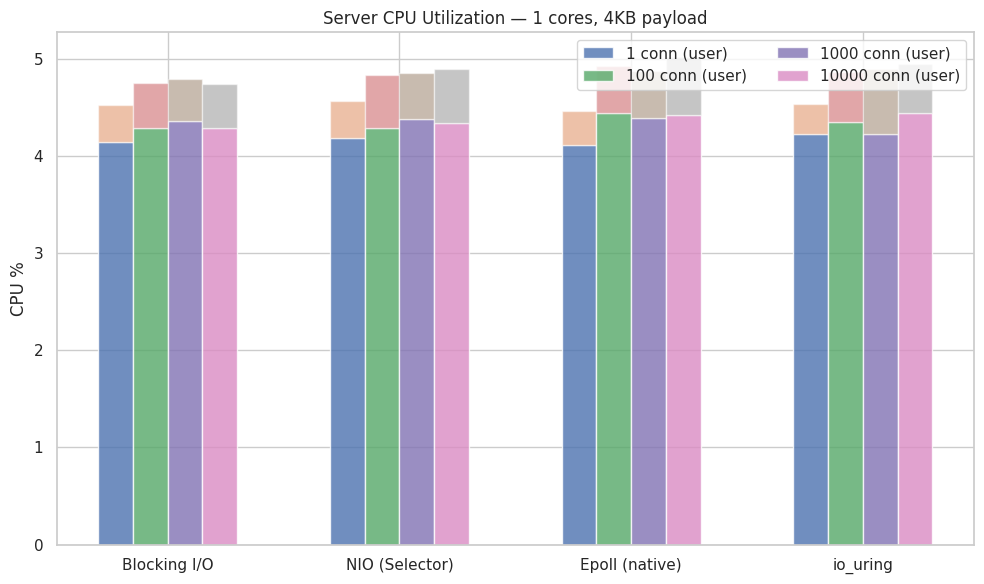

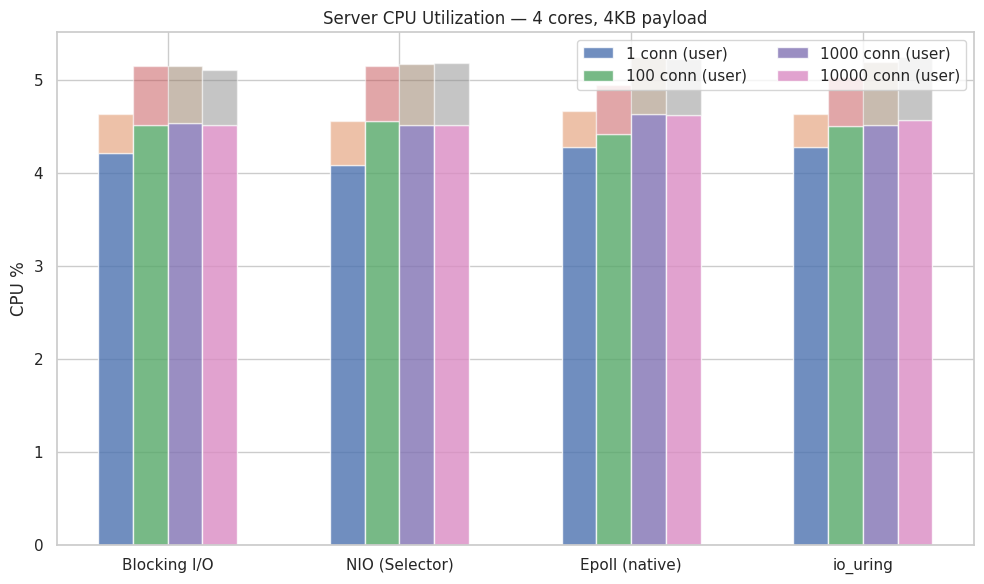

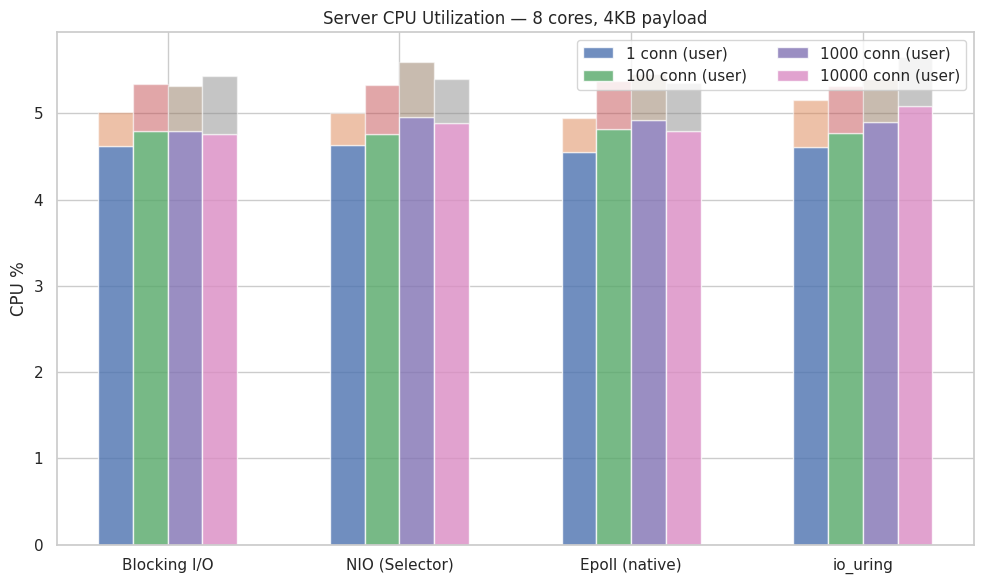

In [6]:
if 'cpu' in data:
    df = data['cpu']
    agg = df.groupby(['model', 'cores', 'connections', 'data_size']).agg(
        server_user=('server_user_pct', 'mean'),
        server_sys=('server_sys_pct', 'mean'),
    ).reset_index()
    
    for cores in sorted(agg['cores'].unique()):
        subset = agg[(agg['cores'] == cores) & (agg['data_size'] == 4096)]
        if subset.empty:
            continue
        
        fig, ax = plt.subplots(figsize=(10, 6))
        x = range(len(MODELS))
        width = 0.15
        
        for i, conns in enumerate([1, 100, 1000, 10000]):
            user_vals = []
            sys_vals = []
            for model in MODELS:
                row = subset[(subset['model'] == model) & (subset['connections'] == conns)]
                if not row.empty:
                    user_vals.append(row['server_user'].values[0])
                    sys_vals.append(row['server_sys'].values[0])
                else:
                    user_vals.append(0)
                    sys_vals.append(0)
            
            offset = (i - 1.5) * width
            ax.bar([xi + offset for xi in x], user_vals, width, label=f'{conns} conn (user)', alpha=0.8)
            ax.bar([xi + offset for xi in x], sys_vals, width, bottom=user_vals, alpha=0.5)
        
        ax.set_xticks(x)
        ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS])
        ax.set_ylabel('CPU %')
        ax.set_title(f'Server CPU Utilization — {cores} cores, 4KB payload')
        ax.legend(ncol=2)
        plt.tight_layout()
        plt.show()
else:
    print('No CPU data available.')

## 4. Context Switches

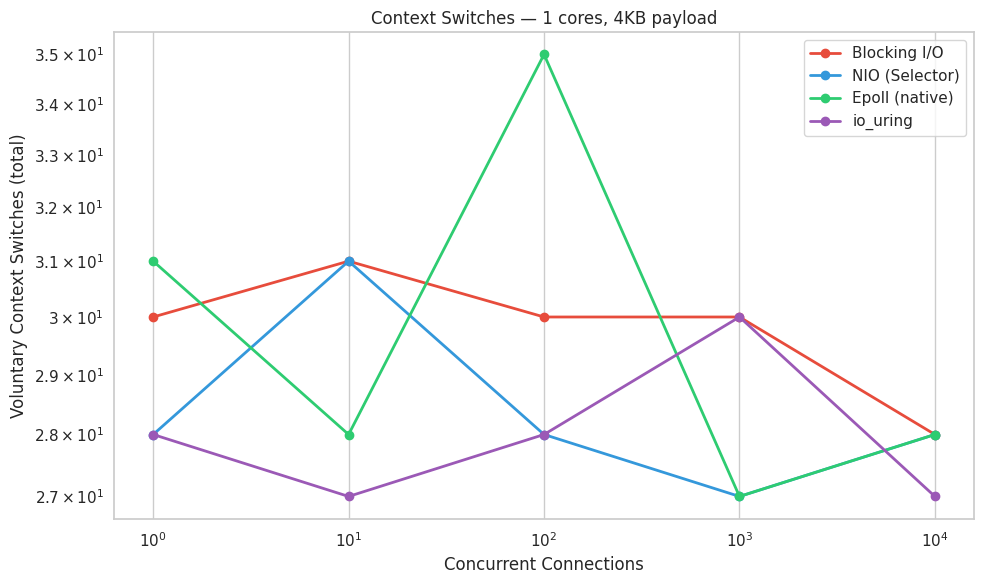

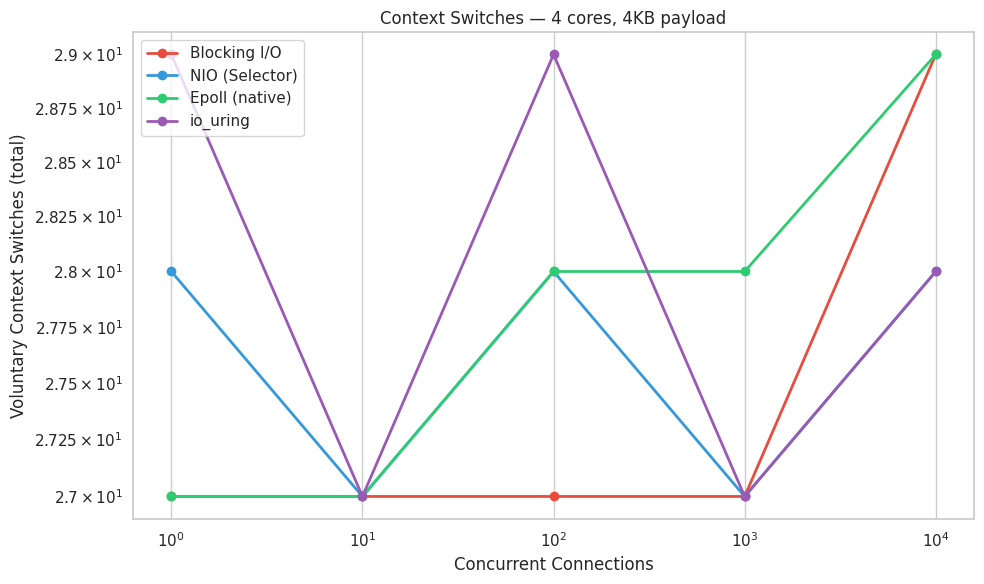

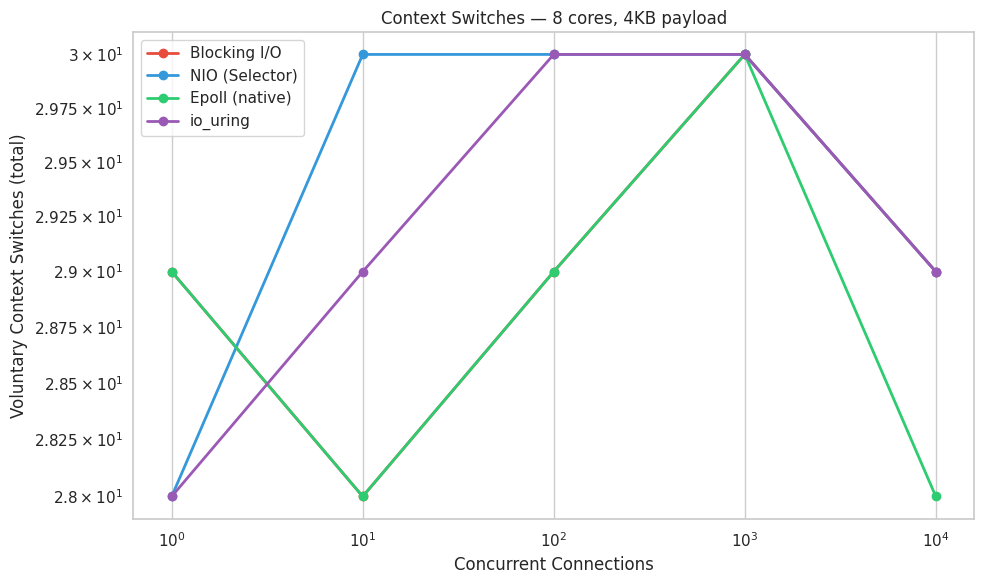

In [7]:
if 'context_switches' in data:
    df = data['context_switches']
    # Use max value per test (cumulative counters)
    agg = df.groupby(['model', 'cores', 'connections', 'data_size']).agg(
        vol=('server_voluntary', 'max'),
        invol=('server_involuntary', 'max'),
    ).reset_index()
    
    for cores in sorted(agg['cores'].unique()):
        subset = agg[(agg['cores'] == cores) & (agg['data_size'] == 4096)]
        if subset.empty:
            continue
        
        fig, ax = plt.subplots(figsize=(10, 6))
        for model in MODELS:
            m = subset[subset['model'] == model]
            if not m.empty:
                ax.plot(m['connections'], m['vol'], 'o-',
                        color=MODEL_COLORS[model], label=MODEL_LABELS[model], linewidth=2)
        
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Concurrent Connections')
        ax.set_ylabel('Voluntary Context Switches (total)')
        ax.set_title(f'Context Switches — {cores} cores, 4KB payload')
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print('No context switch data available.')

## 5. Syscall Breakdown

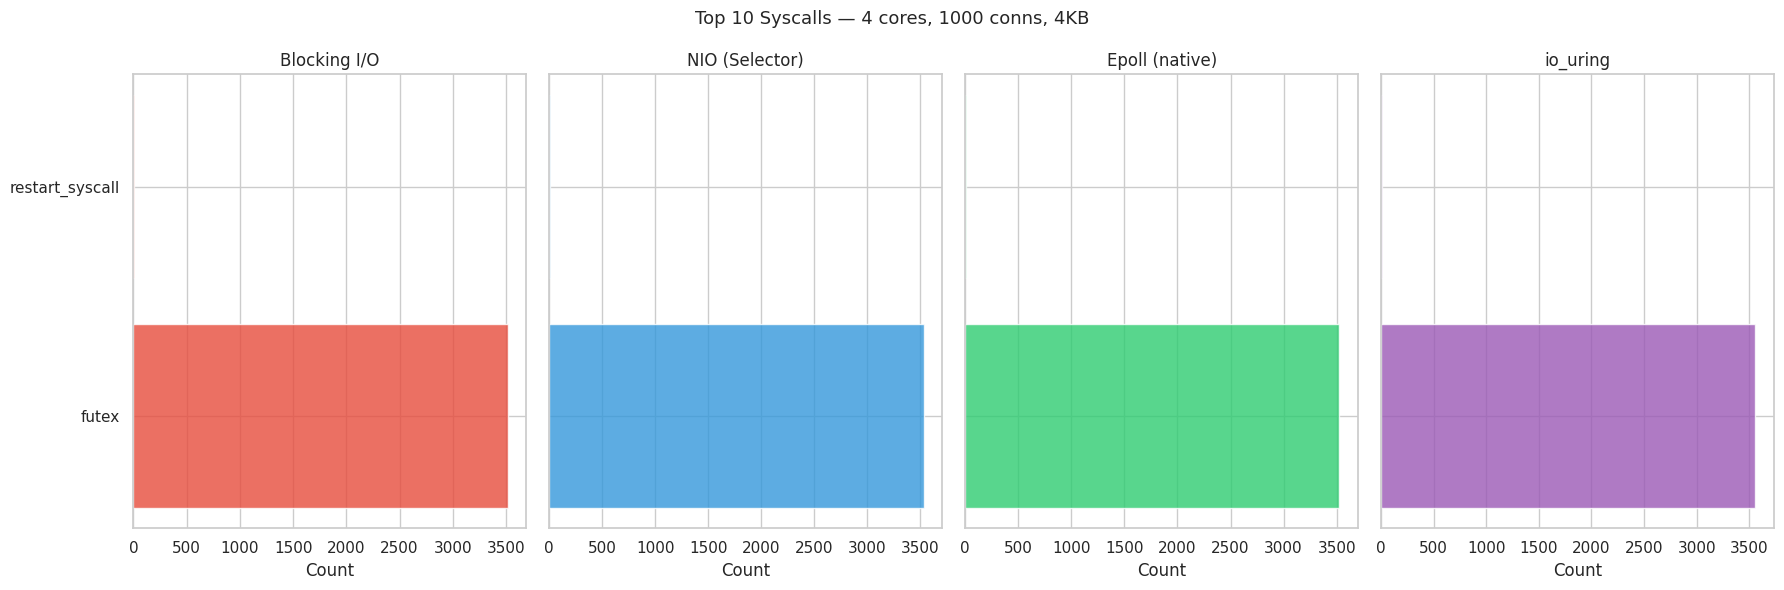

In [8]:
if 'syscalls' in data:
    df = data['syscalls']
    
    # Show syscall distribution for 4 cores, 1000 connections, 4KB
    subset = df[(df['cores'] == 4) & (df['connections'] == 1000) & (df['data_size'] == 4096) & (df['run'] == 1)]
    
    if not subset.empty:
        fig, axes = plt.subplots(1, len(MODELS), figsize=(18, 6), sharey=True)
        if len(MODELS) == 1:
            axes = [axes]
        
        for ax, model in zip(axes, MODELS):
            m = subset[subset['model'] == model].nlargest(10, 'count')
            if not m.empty:
                ax.barh(m['syscall_name'], m['count'], color=MODEL_COLORS[model], alpha=0.8)
                ax.set_xlabel('Count')
                ax.set_title(MODEL_LABELS[model])
                ax.invert_yaxis()
        
        fig.suptitle('Top 10 Syscalls — 4 cores, 1000 conns, 4KB', fontsize=13)
        plt.tight_layout()
        plt.show()
    else:
        print('No matching syscall data for selected parameters.')
else:
    print('No syscall data available.')

## 6. Memory Usage

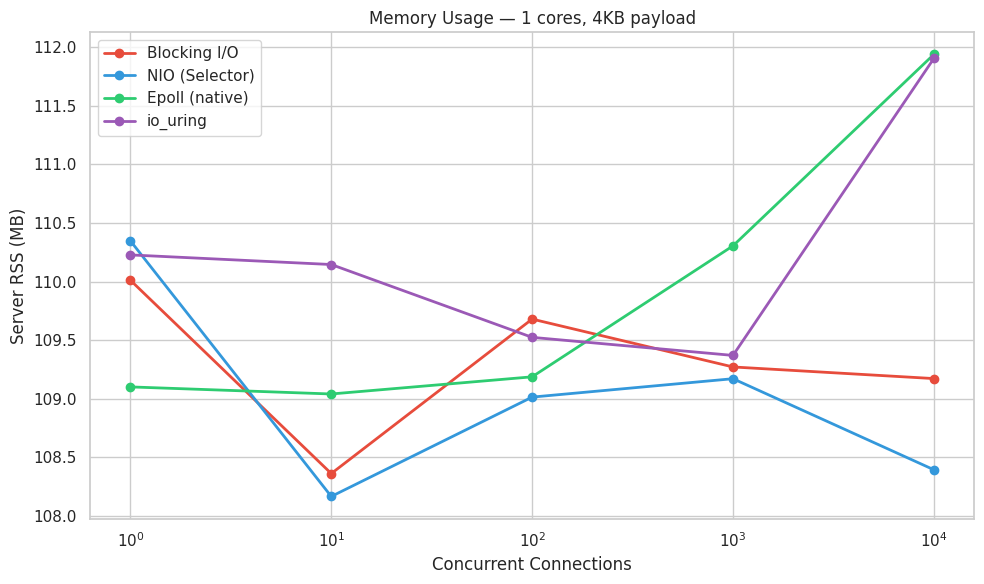

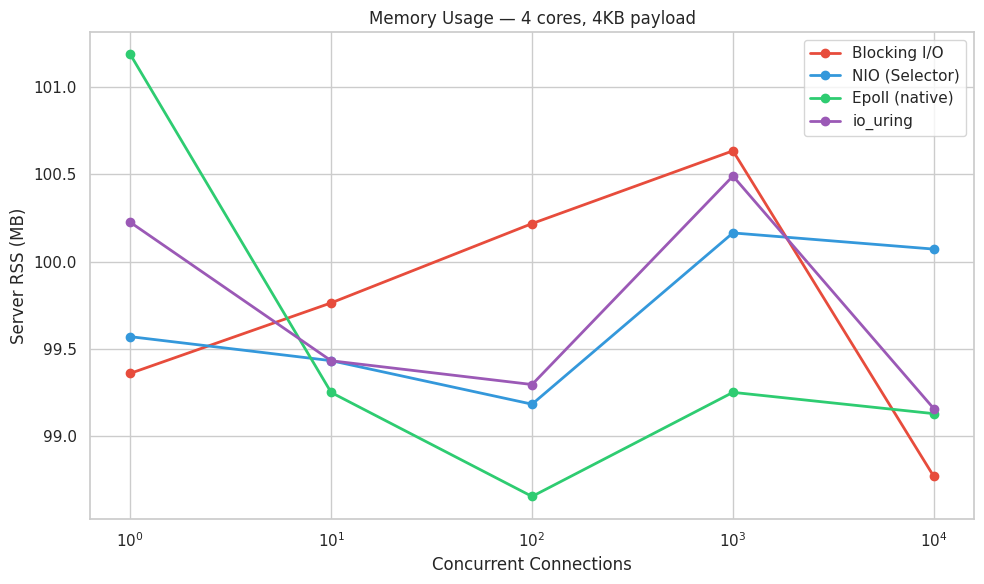

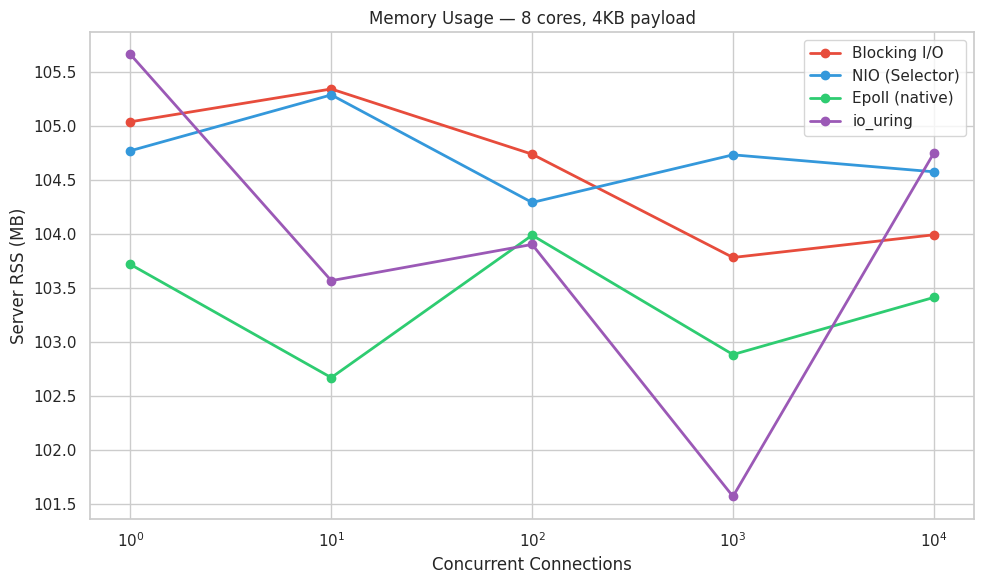

In [9]:
if 'memory' in data:
    df = data['memory']
    agg = df.groupby(['model', 'cores', 'connections', 'data_size'])['server_rss_kb'].mean().reset_index()
    agg['server_rss_mb'] = agg['server_rss_kb'] / 1024
    
    for cores in sorted(agg['cores'].unique()):
        subset = agg[(agg['cores'] == cores) & (agg['data_size'] == 4096)]
        if subset.empty:
            continue
        
        fig, ax = plt.subplots(figsize=(10, 6))
        for model in MODELS:
            m = subset[subset['model'] == model]
            if not m.empty:
                ax.plot(m['connections'], m['server_rss_mb'], 'o-',
                        color=MODEL_COLORS[model], label=MODEL_LABELS[model], linewidth=2)
        
        ax.set_xscale('log')
        ax.set_xlabel('Concurrent Connections')
        ax.set_ylabel('Server RSS (MB)')
        ax.set_title(f'Memory Usage — {cores} cores, 4KB payload')
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print('No memory data available.')

## 7. File Descriptors

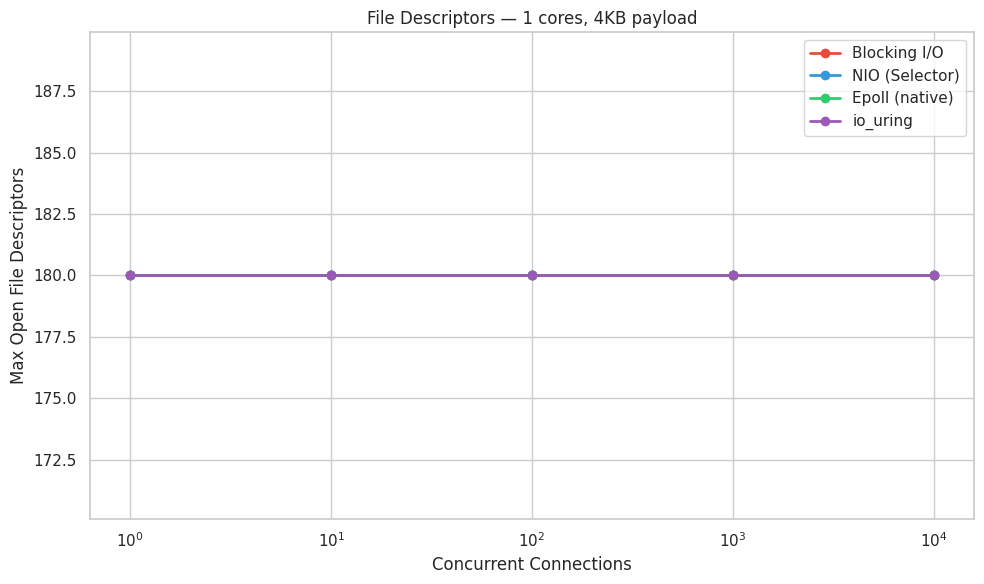

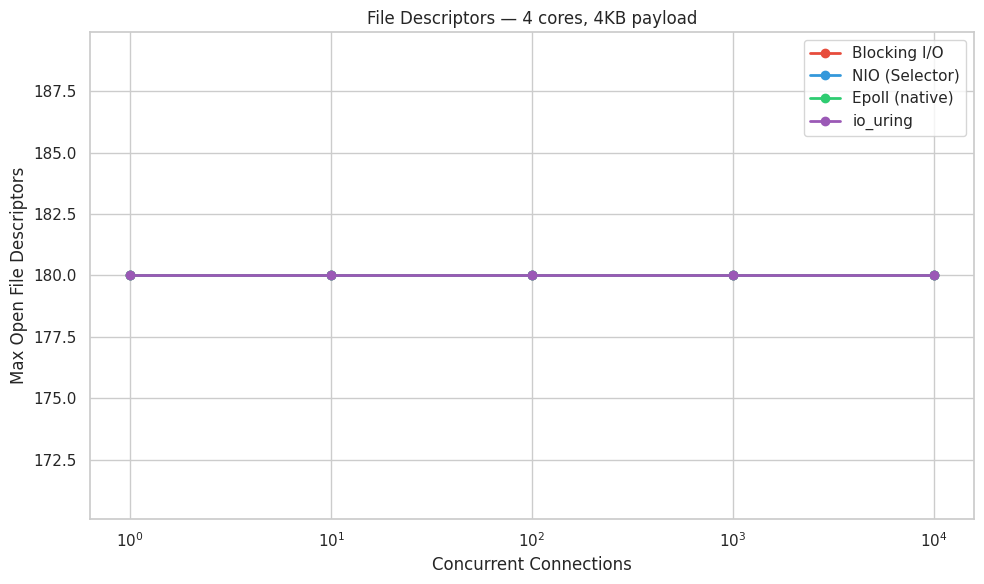

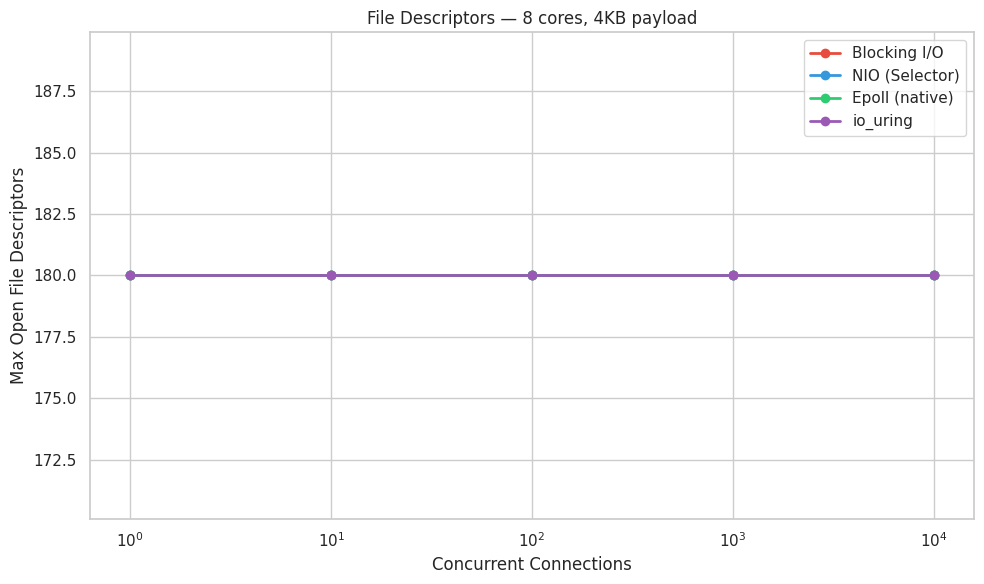

In [10]:
if 'fd_count' in data:
    df = data['fd_count']
    agg = df.groupby(['model', 'cores', 'connections', 'data_size'])['server_fd_count'].max().reset_index()
    
    for cores in sorted(agg['cores'].unique()):
        subset = agg[(agg['cores'] == cores) & (agg['data_size'] == 4096)]
        if subset.empty:
            continue
        
        fig, ax = plt.subplots(figsize=(10, 6))
        for model in MODELS:
            m = subset[subset['model'] == model]
            if not m.empty:
                ax.plot(m['connections'], m['server_fd_count'], 'o-',
                        color=MODEL_COLORS[model], label=MODEL_LABELS[model], linewidth=2)
        
        ax.set_xscale('log')
        ax.set_xlabel('Concurrent Connections')
        ax.set_ylabel('Max Open File Descriptors')
        ax.set_title(f'File Descriptors — {cores} cores, 4KB payload')
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print('No FD data available.')

## 8. Scalability: Throughput across CPU Configurations

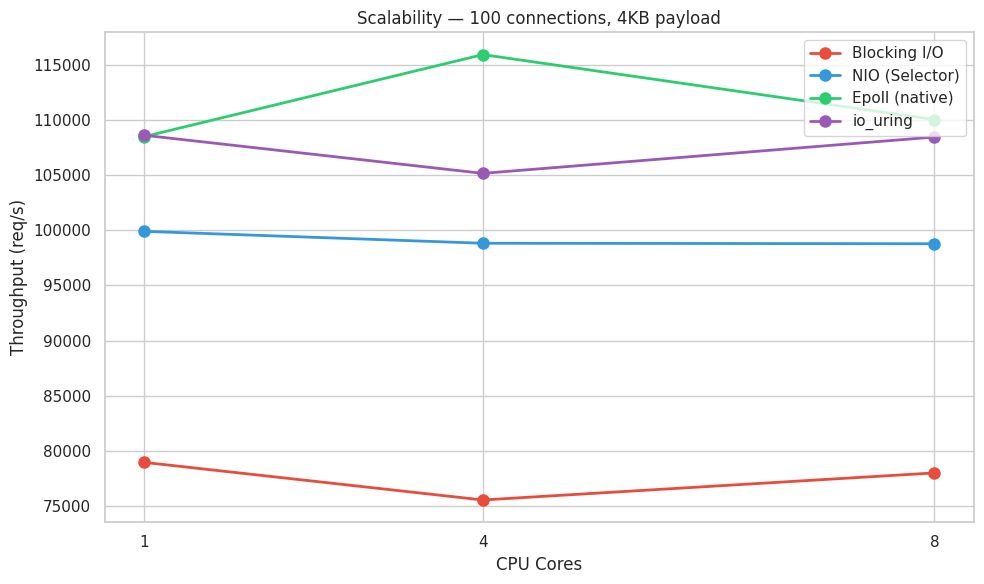

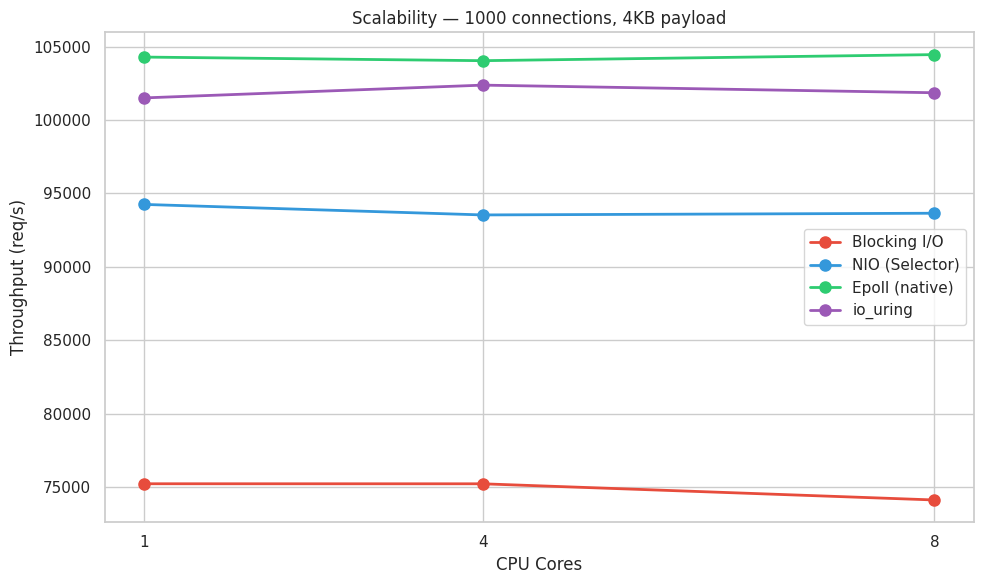

In [11]:
if 'throughput' in data:
    df = data['throughput']
    agg = df.groupby(['model', 'cores', 'connections', 'data_size'])['throughput_rps'].mean().reset_index()
    
    for conns in [100, 1000]:
        subset = agg[(agg['connections'] == conns) & (agg['data_size'] == 4096)]
        if subset.empty:
            continue
        
        fig, ax = plt.subplots(figsize=(10, 6))
        for model in MODELS:
            m = subset[subset['model'] == model].sort_values('cores')
            if not m.empty:
                ax.plot(m['cores'], m['throughput_rps'], 'o-',
                        color=MODEL_COLORS[model], label=MODEL_LABELS[model], linewidth=2, markersize=8)
        
        ax.set_xlabel('CPU Cores')
        ax.set_ylabel('Throughput (req/s)')
        ax.set_title(f'Scalability — {conns} connections, 4KB payload')
        ax.set_xticks([1, 4, 8])
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print('No throughput data for scalability chart.')

## 9. Summary Table

In [12]:
if 'throughput' in data and 'latency' in data:
    tp = data['throughput'].groupby(['model', 'cores', 'connections', 'data_size'])['throughput_rps'].mean().reset_index()
    lat = data['latency'].groupby(['model', 'cores', 'connections', 'data_size'])[['p50_us', 'p99_us']].mean().reset_index()
    
    merged = tp.merge(lat, on=['model', 'cores', 'connections', 'data_size'], how='inner')
    
    # Show summary for 4 cores, 4KB
    summary = merged[(merged['cores'] == 4) & (merged['data_size'] == 4096)]
    summary = summary[['model', 'connections', 'throughput_rps', 'p50_us', 'p99_us']]
    summary.columns = ['Model', 'Connections', 'Throughput (RPS)', 'p50 (μs)', 'p99 (μs)']
    summary['Throughput (RPS)'] = summary['Throughput (RPS)'].round(0).astype(int)
    summary['p50 (μs)'] = summary['p50 (μs)'].round(0).astype(int)
    summary['p99 (μs)'] = summary['p99 (μs)'].round(0).astype(int)
    
    display(summary.sort_values(['Connections', 'Model']).reset_index(drop=True))
else:
    print('Insufficient data for summary table.')

,Model,Connections,Throughput (RPS),p50 (μs),p99 (μs)
0,blocking,1,10384,82,122
1,epoll,1,15738,49,77
2,iouring,1,15601,50,76
3,nio,1,13858,58,89
4,blocking,10,54699,157,277
5,epoll,10,74479,108,201
6,iouring,10,68852,119,237
7,nio,10,57423,155,239
8,blocking,100,75526,699,1111
9,epoll,100,115960,794,1888
